# Wigner-Seitz Defect Analysis

This notebook demonstrates the Wigner-Seitz cell analysis for detecting point defects:
- **Vacancies**: Empty lattice sites (occupancy = 0)
- **Interstitials**: Excess atoms at a site (occupancy > 1)
- **Antisites**: Wrong atom type at a site (for multi-component systems)

The algorithm assigns each atom to its nearest reference lattice site.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ase.build import bulk
import pyscal3

## 1. Perfect Crystal (No Defects)

In [2]:
# Create perfect FCC Cu reference
reference = bulk("Cu", "fcc", cubic=True).repeat(4)
current = reference.copy()

# Analyze  
result = pyscal3.wigner_seitz_analysis(current, reference)
print(f"Number of atoms: {len(current)}")
print(f"Vacancies: {result['vacancy_count']}")
print(f"Interstitials: {result['interstitial_count']}")
print(f"All sites occupied:", np.all(result['occupancy'] == 1))

Number of atoms: 256
Vacancies: 0
Interstitials: 0
All sites occupied: True


## 2. Creating Vacancies

In [3]:
# Remove some atoms to create vacancies
defected = reference.copy()
vacancy_sites = [0, 50, 100, 150]  # Sites to leave empty
for i in sorted(vacancy_sites, reverse=True):
    del defected[i]

result = pyscal3.wigner_seitz_analysis(defected, reference)
print(f"Vacancy count: {result['vacancy_count']}")
print(f"Vacant site indices: {result['vacancy_indices'][:10]}...")  # First few
print()
print("Site occupancy distribution:")
unique, counts = np.unique(result['occupancy'], return_counts=True)
for occ, cnt in zip(unique, counts):
    print(f"  Occupancy {occ}: {cnt} sites")

Vacancy count: 4
Vacant site indices: [  0  50 100 150]...

Site occupancy distribution:
  Occupancy 0: 4 sites
  Occupancy 1: 252 sites


## 3. Creating Interstitials

In [4]:
# Add atoms close to existing sites (interstitials)
with_interstitials = reference.copy()

# Add 3 interstitials near sites 0, 10, 20
for site in [0, 10, 20]:
    pos = with_interstitials[site].position
    with_interstitials.append("Cu")
    with_interstitials.positions[-1] = pos + [0.2, 0.2, 0.2]

result = pyscal3.wigner_seitz_analysis(with_interstitials, reference)
print(f"Interstitial count: {result['interstitial_count']}")
print(f"Sites with excess atoms: {result['interstitial_sites']}")
print()
print("Site occupancy distribution:")
unique, counts = np.unique(result['occupancy'], return_counts=True)
for occ, cnt in zip(unique, counts):
    print(f"  Occupancy {occ}: {cnt} sites")

Interstitial count: 3
Sites with excess atoms: [ 0 10 20]

Site occupancy distribution:
  Occupancy 1: 253 sites
  Occupancy 2: 3 sites


## 4. Frenkel Pair (Vacancy + Interstitial)

In [5]:
# Create Frenkel pair: move atom from one site to near another
frenkel = reference.copy()
frenkel.positions[0] = frenkel.positions[50] + [0.3, 0.0, 0.0]

result = pyscal3.wigner_seitz_analysis(frenkel, reference)
print(f"Vacancies: {result['vacancy_count']}")
print(f"Interstitials: {result['interstitial_count']}")
print(f"Vacant sites: {result['vacancy_indices']}")
print(f"Doubly-occupied sites: {result['interstitial_sites']}")

Vacancies: 1
Interstitials: 1
Vacant sites: [0]
Doubly-occupied sites: [50]


## 5. Affine Mapping for Thermal Expansion

In [6]:
# Simulate thermal expansion - atoms drift from ideal sites
expanded = reference.copy()
expanded.set_cell(expanded.get_cell() * 1.03, scale_atoms=True)  # 3% expansion

# Without affine mapping
result_no_map = pyscal3.wigner_seitz_analysis(expanded, reference, affine_mapping="none")
print("Without affine mapping:")
print(f"  Apparent 'defects' (vacancies + interstitials): {result_no_map['vacancy_count'] + result_no_map['interstitial_count']}")

# With affine mapping
result_mapped = pyscal3.wigner_seitz_analysis(expanded, reference, affine_mapping="to_reference")
print("\nWith affine mapping:")
print(f"  Defects: {result_mapped['vacancy_count'] + result_mapped['interstitial_count']}")

Without affine mapping:
  Apparent 'defects' (vacancies + interstitials): 0

With affine mapping:
  Defects: 0


## 6. Per-Type Occupancies (Antisite Detection)

In [7]:
# Create ordered binary alloy
ref_binary = bulk("NaCl", crystalstructure="rocksalt", a=5.64, cubic=True).repeat(2)
current_binary = ref_binary.copy()

print("Original composition:", dict((s, (np.array(ref_binary.get_chemical_symbols()) == s).sum()) 
      for s in set(ref_binary.get_chemical_symbols())))

# Create antisite by swapping Na and Cl
na_sites = [i for i, s in enumerate(ref_binary.get_chemical_symbols()) if s == "Na"]
cl_sites = [i for i, s in enumerate(ref_binary.get_chemical_symbols()) if s == "Cl"]
current_binary.symbols[na_sites[0]] = "Cl"
current_binary.symbols[cl_sites[0]] = "Na"

result = pyscal3.wigner_seitz_analysis(current_binary, ref_binary, per_type_occupancies=True)
print(f"\nVacancies: {result['vacancy_count']}")
print(f"Interstitials: {result['interstitial_count']}")
print("\nPer-type occupancies show antisites:")
for t, occ in result['occupancy_by_type'].items():
    print(f"  {t}: {np.sum(occ)} atoms assigned")

Original composition: {'Na': np.int64(32), 'Cl': np.int64(32)}

Vacancies: 0
Interstitials: 0

Per-type occupancies show antisites:
  Cl: 32 atoms assigned
  Na: 32 atoms assigned


## 7. Convenience Function: identify_defect_atoms

In [8]:
# Use identify_defect_atoms for a full defect analysis
defected = reference.copy()
del defected[0]  # Vacancy
defected.positions[1] = defected.positions[50] + [0.2, 0, 0]  # Frenkel

analysis = pyscal3.identify_defect_atoms(defected, reference)
print(f"Summary: {analysis['defect_summary']}")
print(f"\nAtom classifications:")
print(f"  Perfect (singly-occupied): {np.sum(analysis['perfect_mask'])}")
print(f"  At interstitial sites: {np.sum(analysis['interstitial_mask'])}")
print(f"\nVacancy positions:")
print(analysis['vacancy_positions'])

Summary: 2 vacancies, 1 interstitials

Atom classifications:
  Perfect (singly-occupied): 253
  At interstitial sites: 2

Vacancy positions:
[[0.    0.    0.   ]
 [1.805 0.    1.805]]


## 8. Data Stored on Atoms

In [9]:
# Results are stored on the atoms object
atoms = reference.copy()
del atoms[10]
pyscal3.wigner_seitz_analysis(atoms, reference)

print("Stored in atoms.arrays:")
print(f"  pyscal_ws_site_index: {atoms.arrays['pyscal_ws_site_index'][:5]}...")
print(f"  pyscal_ws_occupancy: {atoms.arrays['pyscal_ws_occupancy'][:5]}...")
print()
print("Stored in atoms.info:")
print(f"  pyscal_ws_vacancy_count: {atoms.info['pyscal_ws_vacancy_count']}")
print(f"  pyscal_ws_interstitial_count: {atoms.info['pyscal_ws_interstitial_count']}")

Stored in atoms.arrays:
  pyscal_ws_site_index: [0 1 2 3 4]...
  pyscal_ws_occupancy: [1 1 1 1 1]...

Stored in atoms.info:
  pyscal_ws_vacancy_count: 1
  pyscal_ws_interstitial_count: 0


## 9. Visualization Example

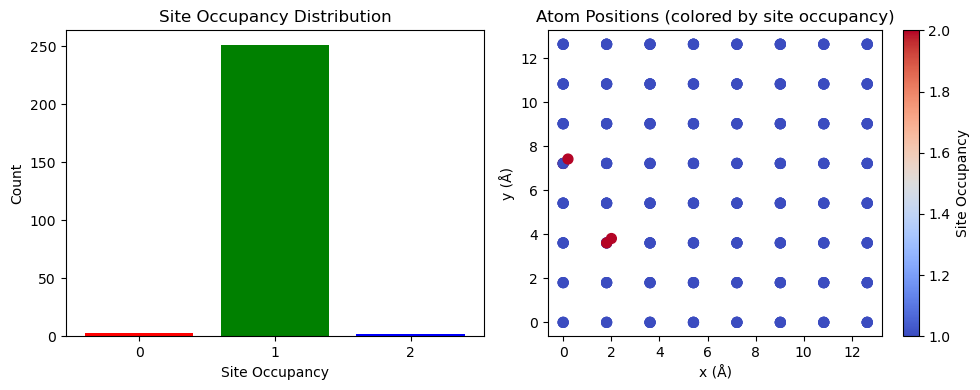

Red bar: 3 vacancies
Blue bar: 2 interstitials


In [10]:
# Visualize occupancy distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Create system with mixed defects
mixed = reference.copy()
for i in [0, 10, 20]:  # Vacancies
    del mixed[0]
for i in [30, 40]:  # Interstitials
    pos = reference[i].position
    mixed.append("Cu")
    mixed.positions[-1] = pos + [0.2, 0.2, 0]

result = pyscal3.wigner_seitz_analysis(mixed, reference)

# Histogram of site occupancies
axes[0].bar(np.arange(3), [
    np.sum(result['occupancy'] == 0),
    np.sum(result['occupancy'] == 1),
    np.sum(result['occupancy'] == 2)
], color=['red', 'green', 'blue'])
axes[0].set_xlabel('Site Occupancy')
axes[0].set_ylabel('Count')
axes[0].set_title('Site Occupancy Distribution')
axes[0].set_xticks([0, 1, 2])

# Positions colored by occupancy
pos = mixed.get_positions()
occ = result['occupancy'][result['site_index']]
scatter = axes[1].scatter(pos[:, 0], pos[:, 1], c=occ, cmap='coolwarm', s=50)
plt.colorbar(scatter, ax=axes[1], label='Site Occupancy')
axes[1].set_xlabel('x (Å)')
axes[1].set_ylabel('y (Å)')
axes[1].set_title('Atom Positions (colored by site occupancy)')

plt.tight_layout()
plt.show()

print(f"Red bar: {result['vacancy_count']} vacancies")
print(f"Blue bar: {result['interstitial_count']} interstitials")